# **Projektarbeit: Heart Attack Analysis & Prediction**

**Kurs:** Maschinelles Lernen (MaLe-AD23-HS24)  
**Autor/in:** Xenia Zbinden  
**Datum:** 23.12.2024


Die Daten sind von Kaggle, jedoch gibt es das orginale Datenset nicht mehr (https://www.kaggle.com/rashikrahmanpritom/datasets).

---

## **1. Einführung**



In der Schweiz erleiden circa 30'000 Personen jedes Jahr einen Herzinfarkt. Laut dem Universitätsspital Zürich kann durch gesunde Ernährung aber auch regelmässigen Arztbesuche, bei welchem zum Beispiel der Cholesterinwert getestet wird, Herzinfarkte vorgebeugt werden.
Mit diesem Projekt soll erforscht werden, wie gut man Herzinfarkte vorhersagen kann mithilfe eines Modells. Allenfalls könnten dann solche Modelle auch flächendeckend für Diagnosen genutzt werden. Das Ziel von dem Projekt ist es auch aufzuzeigen, wie man ein binäres Klassifikationsproblem angehen kann.

Für das Projekt wird ein Datensatz von Kaggl trainiert, die Variablen und deren Erklärungen werden unten aufgezeigt. Das Klassifikationsproblem hat eine binäre Zielvariabel und sagt entweder eine hohe Chance für einen Herzinfarkt voraus oder nicht (ja/nein bzw. 1/0). Es hat 13 Features, welche alle nummerisch sind.

Die Variabeln im Detail erklärt:
- `age`: Alter von den Patienten in Jahren
- `sex`: Geschlecht von Patienten (0: Weiblich, 1: Männlich)
- `cp`: Brustschmerzen (1 -4)
- `trtbps`: Ruheblutdruck (in mm Hg)
- `chol`: Cholestoral in mg/dl
- `fbs`: nüchtender Blutzucker (>120 mg/dl, 1= true, 0 = false)
- `restecg`: EKG Ergebnisse (0-2)
- `thalachh`: Maximum Herzrate
- `exng`: Belastungbedingte Angina pectoris (0= nein, 1= ja)
- `oldpeak`: ST Senkung
- `slp`: Steigung des Spitzen-ST-Segments bei Belastung (0-2)
- `caa`: Anzahl an verengten Hauptgefässe (1-4)
- `thall`: Thallium Stress Testresulate (0,3)
- `output`: Zielvariabel (0= kleine Chance,1= hohe Chance)

---
## **2. Setup**




Our color palette:


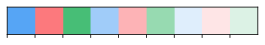

In [1]:
# Basic imports
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# Enable vectorized graphics
%config InlineBackend.figure_formats = ["svg"]

# Setup plotting
PALETTE = [ (0.341, 0.648, 0.962, 1.0), 
            (0.990, 0.476, 0.494, 1.0), 
            (0.281, 0.749, 0.463, 1.0), 
            (0.629, 0.802, 0.978, 1.0), 
            (0.994, 0.705, 0.715, 1.0), 
            (0.595, 0.858, 0.698, 1.0), 
            (0.876, 0.934, 0.992, 1.0), 
            (0.998, 0.901, 0.905, 1.0), 
            (0.865, 0.952, 0.899, 1.0) ]

# For more color palettes, see here:
# https://seaborn.pydata.org/tutorial/color_palettes.html
# https://matplotlib.org/stable/users/explain/colors/colormaps.html
#PALETTE = sns.color_palette("husl", 8)
#PALETTE = sns.color_palette("viridis", 10)
#PALETTE = sns.color_palette("Set2", 10)

print("Our color palette:")
sns.palplot(PALETTE, size=0.5)

sns.set_style("whitegrid")
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=PALETTE)
plt.rcParams["figure.dpi"] = 300    # High-res figures (DPI)
plt.rcParams["pdf.fonttype"] = 42   # Editable text in PDF

**weitere Packages**

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import RFE
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, RocCurveDisplay
from sklearn.model_selection import cross_val_score, RepeatedStratifiedKFold
from sklearn.metrics import confusion_matrix
from imblearn.metrics import classification_report_imbalanced

---
## **3. Präprozessierung**



Es sind zwei Datensätze, welche nun geladen werden und angeschaut werden.

In [4]:
# Load the data
df = pd.read_csv("data/heart.csv")
df.head()


,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
df_ = pd.read_csv("data/o2Saturation.csv")
df_.head()

#Check if the number of rows match
print(f"heart.csv rows: {df.shape[0]}, o2Saturation.csv rows: {df_.shape[0]}")

#df["o2Saturation"] = df1.squeeze()  # Konvertiert die Spalte in eine Serie

heart.csv rows: 303, o2Saturation.csv rows: 3585


Es wird nun klar, dass die Zeilen nicht übereinstimmen und durch die Dokumentation wird auch nicht ganz klar, was das `o2`Feature genau darstellt. Deshalb wird es hier nicht mehr benutzt.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trtbps    303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalachh  303 non-null    int64  
 8   exng      303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slp       303 non-null    int64  
 11  caa       303 non-null    int64  
 12  thall     303 non-null    int64  
 13  output    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [7]:
df.isnull().sum()

age         0
sex         0
cp          0
trtbps      0
chol        0
fbs         0
restecg     0
thalachh    0
exng        0
oldpeak     0
slp         0
caa         0
thall       0
output      0
dtype: int64

In [8]:
df.shape

(303, 14)

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trtbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalachh,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exng,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


Durch die obere Tabelle wird schon klar, dass es einige Outliers hat. Jedoch machen all diese Werte (Outliers) Sinn und sprechen nicht für Fehldaten, weshalb diese nicht weiter behandelt werden.

**Einteilung der Daten**

Diese können wie folgt eingeteilt werden:
- Kontinuierliche Variablen (metrisch): `age`, `trtbps`, `chol`, `thalachh`, `oldpeak`
- Kategorische Variablen (nominal oder ordinal):
    - Ordinal: `cp`, `restecg`
    - Nominal: `sex`, `fbs`, `exng`, `slp`, `caa`, `thall`, `output`


In [10]:
#Splitting the data into categorical and continuous features
categorical_features = ['sex', 'exng', 'caa', 'cp', 'fbs', 'restecg', 'slp', 'thall', 'output']
continuous_features = ["age", "trtbps", "chol", "thalachh", "oldpeak"]

df_categorical = df[categorical_features]
df_numeric = df[continuous_features]

**Kategorielle Daten**

OneHotEncoding ist ein wichtiger Schritt, wird hier aber ausgelassen, da alle kategorischen Daten schon aufbereitet sind. 

In [11]:
#Encoding the categorical features
#encoder = OneHotEncoder(sparse_output=False, drop='first') 
#encoded_array = encoder.fit_transform(df_categorical)
#df_categorical_encoded = pd.DataFrame(encoded_array, 
                                       #columns=encoder.get_feature_names_out(categorical_features),
                                       #index=df.index)  

**Kontinuierliche Daten**

Die verschiedenen Scaler skalieren die Daten jeweils anders. Weiter unten wird dann auch noch erleutert wieso man sich für den StandardScaler entschieden hat.

In [12]:
#Scaling the continuous features
scaler = StandardScaler()
#scaler = MinMaxScaler()
#scaler = RobustScaler()

df_numeric_scaled = scaler.fit_transform(df_numeric)
df_numeric_scaled = pd.DataFrame(df_numeric_scaled, 
                                 columns=df_numeric.columns,
                                 index=df.index) 

In [13]:
#Concatenating the scaled continuous and encoded categorical features
df1 = pd.concat([df_numeric_scaled, df_categorical], axis=1)
print("Shape of final DataFrame:", df1.shape)
df1.head()


Shape of final DataFrame: (303, 14)


,age,trtbps,chol,thalachh,oldpeak,sex,exng,caa,cp,fbs,restecg,slp,thall,output
0,0.952197,0.763956,-0.256334,0.015443,1.087338,1,0,0,3,1,0,0,1,1
1,-1.915313,-0.092738,0.072199,1.633471,2.122573,1,0,0,2,0,1,0,2,1
2,-1.474158,-0.092738,-0.816773,0.977514,0.310912,0,0,0,1,0,0,2,2,1
3,0.180175,-0.663867,-0.198357,1.239897,-0.206705,1,0,0,1,0,1,2,2,1
4,0.290464,-0.663867,2.082050,0.583939,-0.379244,0,1,0,0,0,1,2,2,1


In [14]:
df1.isnull().sum()

age         0
trtbps      0
chol        0
thalachh    0
oldpeak     0
sex         0
exng        0
caa         0
cp          0
fbs         0
restecg     0
slp         0
thall       0
output      0
dtype: int64

Nun werden die Dataframes noch unbenannt für den weiteren Gebrauch.

In [15]:
#Splitting the data into features and target
X = df1.drop(columns="output")
y = df1["output"]

**Zusammenfassung des Kapitels**

Nach diesem Kapitel kann man Folgendes zu den Daten sagen:
- Es hat keine Duplikate.
- Es hat keine fehlende Werte.
- Ebenfalls sieht man bei einigen Variablen, dass sie Ausreisser haben, diese werden nicht geglättet, aber beim weiteren Verarbeiten im Hinterkopf behalten.

Die Daten liegen nun skaliert in Features und Targetvariabel vor.

---

## **4. Explorative Datenanalyse**




### 4.1 Deskriptive Statistik
Um auch noch das df1 anzuschauen, wird hier nochmals die "describe" Funktion angewendet.

In [16]:
df1.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,4.690051e-17,1.001654,-2.797624,-0.757280,0.069886,0.731619,2.496240
trtbps,303.0,-7.035077e-16,1.001654,-2.148802,-0.663867,-0.092738,0.478391,3.905165
chol,303.0,-1.113887e-16,1.001654,-2.324160,-0.681494,-0.121055,0.545674,6.140401
thalachh,303.0,-6.800574e-16,1.001654,-3.439267,-0.706111,0.146634,0.715131,2.289429
oldpeak,303.0,2.345026e-17,1.001654,-0.896862,-0.896862,-0.206705,0.483451,4.451851
sex,303.0,6.831683e-01,0.466011,0.000000,0.000000,1.000000,1.000000,1.000000
exng,303.0,3.267327e-01,0.469794,0.000000,0.000000,0.000000,1.000000,1.000000
caa,303.0,7.293729e-01,1.022606,0.000000,0.000000,0.000000,1.000000,4.000000
cp,303.0,9.669967e-01,1.032052,0.000000,0.000000,1.000000,2.000000,3.000000
fbs,303.0,1.485149e-01,0.356198,0.000000,0.000000,0.000000,0.000000,1.000000


### 4.2 Korrelationsanalyse
Die Korrelationsanalyse ist wichtig um Abhängigkeiten festzustellen.

In [17]:
#Correlation Matrix
corr = df1.corr()
corr

,age,trtbps,chol,thalachh,oldpeak,sex,exng,caa,cp,fbs,restecg,slp,thall,output
age,1.000000,0.279351,0.213678,-0.398522,0.210013,-0.098447,0.096801,0.276326,-0.068653,0.121308,-0.116211,-0.168814,0.068001,-0.225439
trtbps,0.279351,1.000000,0.123174,-0.046698,0.193216,-0.056769,0.067616,0.101389,0.047608,0.177531,-0.114103,-0.121475,0.062210,-0.144931
chol,0.213678,0.123174,1.000000,-0.009940,0.053952,-0.197912,0.067023,0.070511,-0.076904,0.013294,-0.151040,-0.004038,0.098803,-0.085239
thalachh,-0.398522,-0.046698,-0.009940,1.000000,-0.344187,-0.044020,-0.378812,-0.213177,0.295762,-0.008567,0.044123,0.386784,-0.096439,0.421741
oldpeak,0.210013,0.193216,0.053952,-0.344187,1.000000,0.096093,0.288223,0.222682,-0.149230,0.005747,-0.058770,-0.577537,0.210244,-0.430696
sex,-0.098447,-0.056769,-0.197912,-0.044020,0.096093,1.000000,0.141664,0.118261,-0.049353,0.045032,-0.058196,-0.030711,0.210041,-0.280937
exng,0.096801,0.067616,0.067023,-0.378812,0.288223,0.141664,1.000000,0.115739,-0.394280,0.025665,-0.070733,-0.257748,0.206754,-0.436757
caa,0.276326,0.101389,0.070511,-0.213177,0.222682,0.118261,0.115739,1.000000,-0.181053,0.137979,-0.072042,-0.080155,0.151832,-0.391724
cp,-0.068653,0.047608,-0.076904,0.295762,-0.149230,-0.049353,-0.394280,-0.181053,1.000000,0.094444,0.044421,0.119717,-0.161736,0.433798
fbs,0.121308,0.177531,0.013294,-0.008567,0.005747,0.045032,0.025665,0.137979,0.094444,1.000000,-0.084189,-0.059894,-0.032019,-0.028046


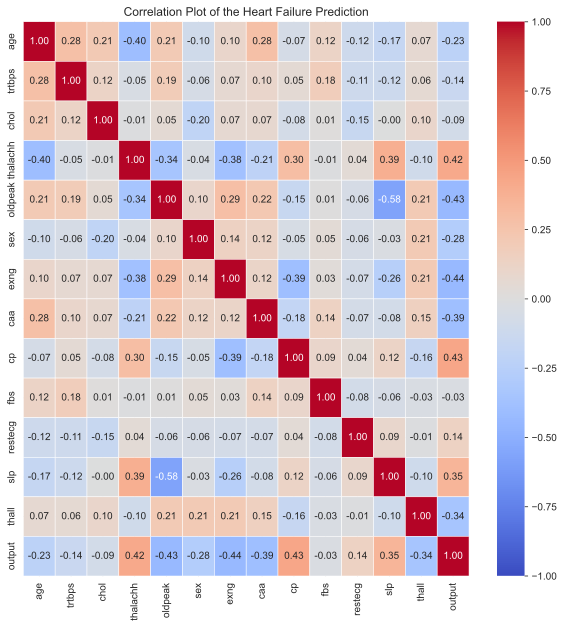

In [18]:
#Plotting the correlation matrix
plt.figure(figsize=(10, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap= "coolwarm", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Plot of the Heart Failure Prediction')
plt.show()

**Korrelationsanalyse Zusammenfassung**: 

- Durch die Heatmap wird ersichtlich, dass es kaum Korrelationen gibt zwischen den Variablen, da alle Zahlen um 0 sind, dies ist schon eher überraschen. Es gibt jedoch welche, die miteinander zumindest ein bisschen korrelieren.
- Features, die mit Output korrelieren:


    - negativ: 
        - `thall`,`caa`, `exgn`, `sex`, `oldpeak`, `trtbps`, `age`
    - positiv:
        - `slp`, `restecg`, `cp`, `thalachh`

### 4.3 Darstellung der Daten

Die Daten werden visualisiert, um sich ein besseres Bild und Gefühl für die Daten zu verschaffen.

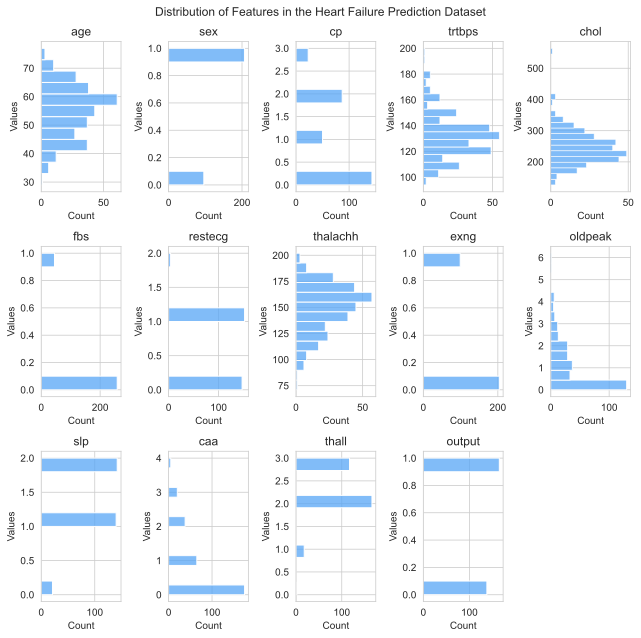

In [19]:
# Histplot
columns = df.columns
fig, axs = plt.subplots(3, 5, figsize=(9, 9))
axs = axs.ravel()
for i, feature in enumerate(df.columns):
    sns.histplot(y=df[feature], ax=axs[i])
    axs[i].set_title(feature)
    axs[i].set_xlabel("Count")
    axs[i].set_ylabel("Values")
for j in range(len(df.columns), len(axs)):
    fig.delaxes(axs[j])
fig.suptitle("Distribution of Features in the Heart Failure Prediction Dataset")
plt.tight_layout()
plt.show()

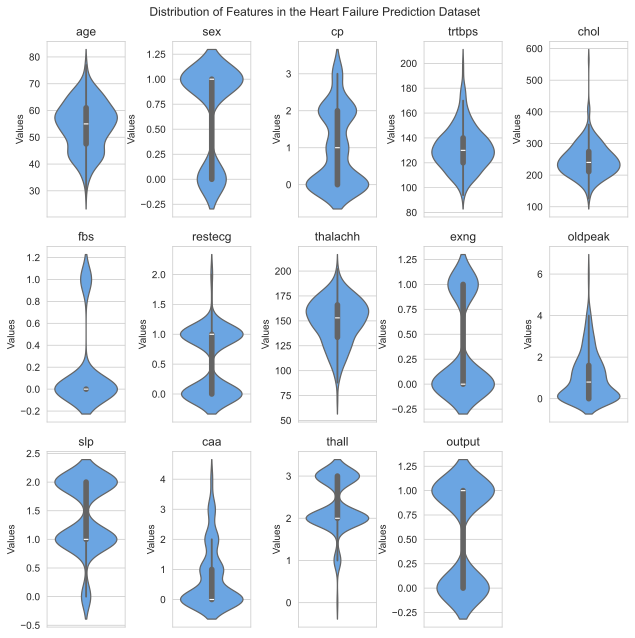

In [20]:
# Violinplot
fig, axs = plt.subplots(3, 5, figsize=(9, 9))
axs = axs.ravel()
for i, feature in enumerate(df.columns):
    sns.violinplot(y=df[feature], ax=axs[i])
    axs[i].set_title(feature)
    axs[i].set_ylabel("Values")
for j in range(len(df.columns), len(axs)):
    fig.delaxes(axs[j])
fig.suptitle("Distribution of Features in the Heart Failure Prediction Dataset")
plt.tight_layout()
plt.show()

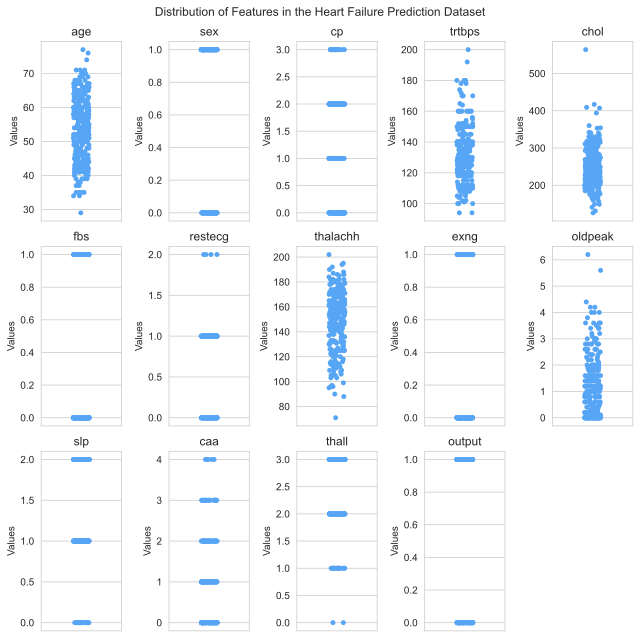

In [21]:
#Stripplot
fig, axs = plt.subplots(3, 5, figsize=(9, 9))
axs = axs.ravel()
for i, feature in enumerate(df.columns):
    sns.stripplot(y=df[feature], ax=axs[i])
    axs[i].set_title(feature)
    axs[i].set_ylabel("Values")
for j in range(len(df.columns), len(axs)):
    fig.delaxes(axs[j])
fig.suptitle("Distribution of Features in the Heart Failure Prediction Dataset")
plt.tight_layout()
plt.show()


- Durch die Plot kann man zum Beispiel Folgendes lesen:
    - dass es viel mehr Männer als Frauen im Datensatz hat.
    - dass das Durchschnittsalter bei etwas unter 60 liegt.
    - dass der Durschnittsruheblutdruck bei um die 130 liegt.
    - dass der Durchschnittscholesterinwert bei etwas unter 250 liegt.
    - dass die durchschnittliche Maximumherzrate ein bisschen über 150 ist.
    - dass die Output Daten sind ausgeglichen verteilt(also keine unverteilte Daten).




### 4.4 Darstellung der kontinuirlichen Merkmale

Die oberen Plots waren zum Teil nicht immer sehr übersichtlich, da die kontinuierlichen und die kategoriellen Merkmale die gleiche Plotart hatten. Nun werden noch extra Plots für die kontinuierlichen Merkmale erstellt.

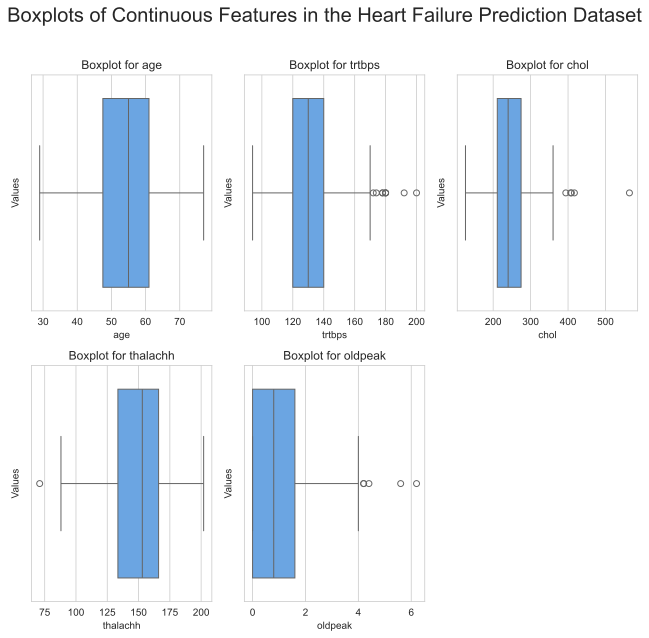

In [22]:
#Boxplot
fig, axs = plt.subplots(2, 3, figsize=(9, 9))
axs = axs.ravel()
for i, feature in enumerate(continuous_features):
    sns.boxplot(x=df[feature], ax=axs[i])
    axs[i].set_title(f"Boxplot for {feature}")
    axs[i].set_xlabel(feature)
    axs[i].set_ylabel("Values")

for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

fig.suptitle("Boxplots of Continuous Features in the Heart Failure Prediction Dataset", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Layout anpassen, um Platz für den Titel zu schaffen
plt.show()

### 4.5 Darstellung der kategoriale Merkmale

Um auch noch die kategoriellen Daten besser zu verstehen, wird nur ein Plot mit diesen Daten erstellt.

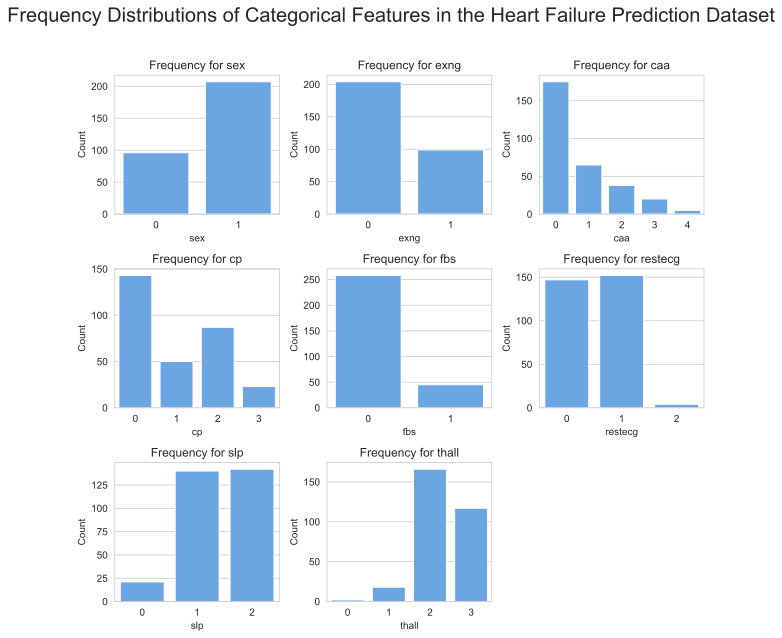

In [23]:
# Countplot
fig, axs = plt.subplots(3, 3, figsize=(9, 9))
axs = axs.ravel()
categorical_features = [feature for feature in categorical_features if feature != 'output']
for i, feature in enumerate(categorical_features):
    sns.countplot(x=df[feature], ax=axs[i])
    axs[i].set_title(f"Frequency for {feature}")
    axs[i].set_xlabel(feature)
    axs[i].set_ylabel("Count")

for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

fig.suptitle("Frequency Distributions of Categorical Features in the Heart Failure Prediction Dataset", fontsize=20)

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Layout anpassen, um Platz für den Titel zu schaffen
plt.show()

### 4.6 Features mit Target vergleichen

**Kontinuierliche**

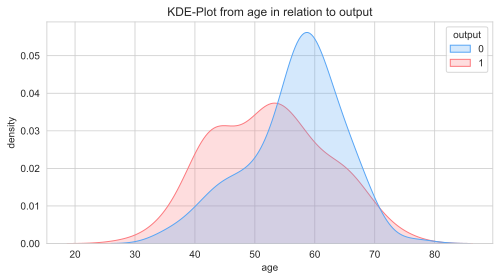

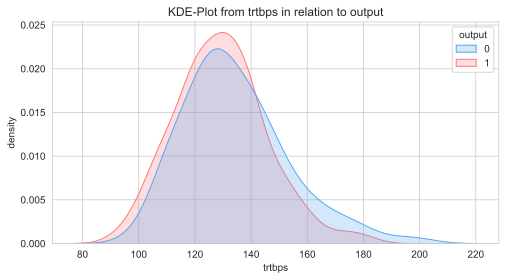

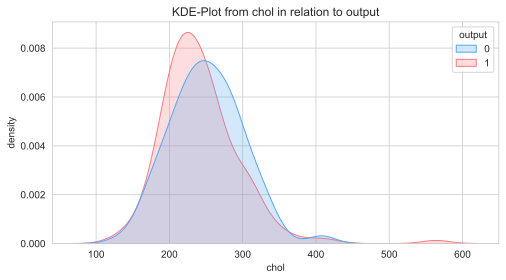

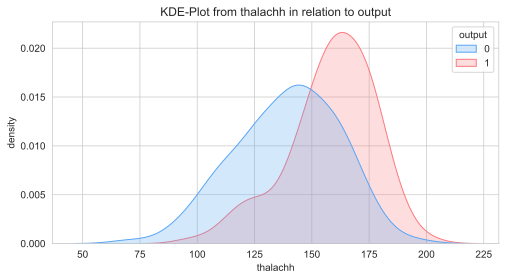

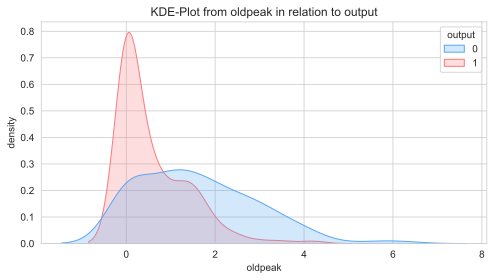

In [24]:
#KDE-Plot for continuous features with hue as output
for feature in continuous_features:
    plt.figure(figsize=(8, 4))
    sns.kdeplot(data=df, x=feature, hue='output', fill=True, common_norm=False)
    plt.title(f"KDE-Plot from {feature} in relation to output")
    plt.xlabel(feature)
    plt.ylabel('density')
    plt.show()

**Kategorisch:**

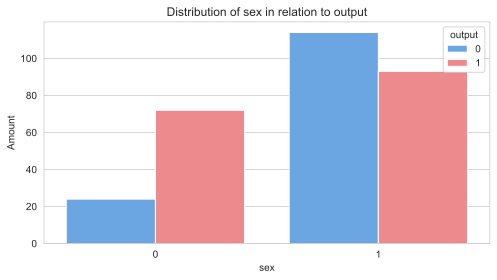

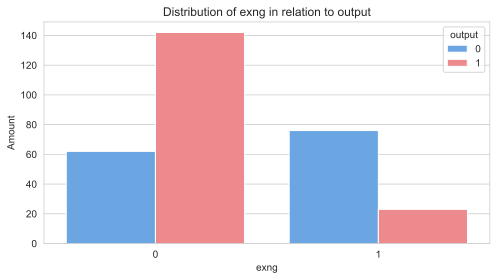

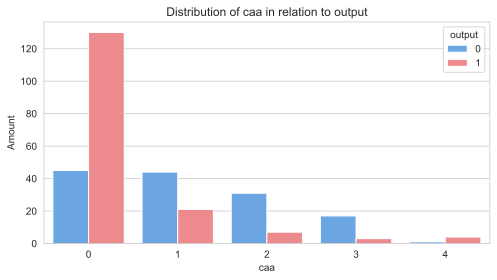

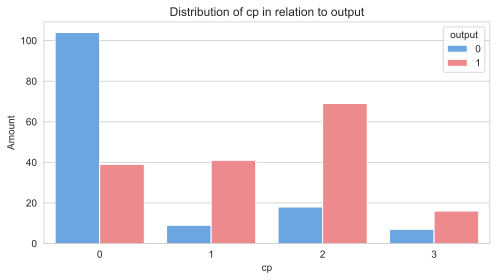

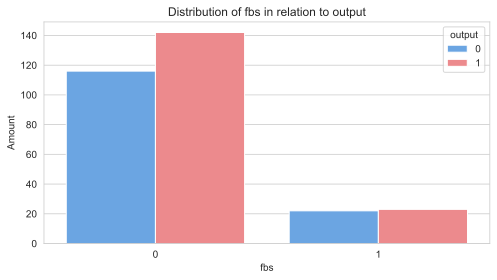

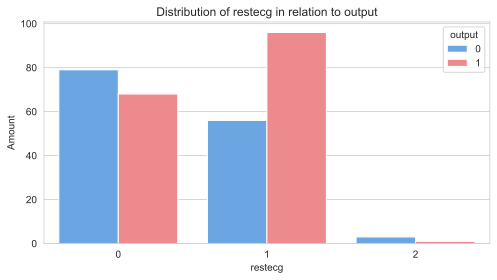

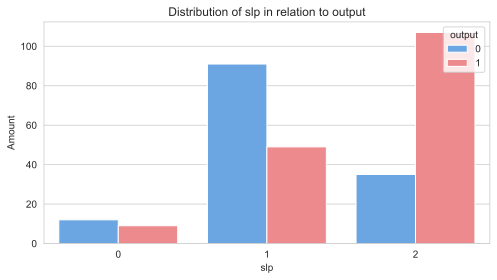

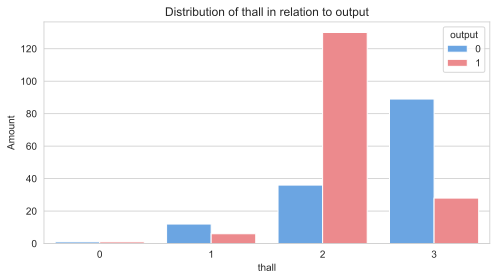

In [25]:
#Countplot for categorical features with hue as output
categorical_features = [feature for feature in categorical_features if feature != 'output']

for feature in categorical_features:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=feature, hue='output')
    plt.title(f"Distribution of {feature} in relation to output")
    plt.xlabel(feature)
    plt.ylabel('Amount')
    plt.legend(title='output', loc='upper right')
    plt.show()


**Zusammenfassung Features im Vergleich zum Target**

Zwischen den Features und der Targetvariabel konnte man einiges drausschliessen. Um es nochmals ins Gedächtnis zu rufen: 0: kleinere Chance auf einen Herzinfarkt, 1: höhere Chance auf einen Herzinfarkt. 

Überaschenderweisse schliesst älteres Alter nicht eher auf eine höhere Chance eines Herzinfarktes. Die Dichte für eine Chance auf einen Herzinfarkt liegt bei ungefähr 50-60, jedoch auch gibt es auch jüngere Personen. Der Ruheblutdruck ist bei beiden Gruppen ungefähr gleich. Der Cholesterinanteil ist bei der 1 Gruppe ein bisschen tiefer, hat jedoch auch mehr Auschläge nach oben. Die maximale Herzrate ist ein bisschen höher bei der Gruppe 1 und ST Senkung ist tiefer bei der Gruppe 1.

Es wurde schon weiter oben festgestellt, dass es viel weniger Frauen in dem Datensatz gibt. Erstaunlich ist, dass die Frauen eher der Gruppe 1 als der Gruppe 0 zugehören. 
Wenn keine Angina pectoris vorliegt, sind die Personen eher in der Gruppe 1. Personen, die einen höheren Brustschmerz angeben, sind eher anfällig auf einen Herzinfarkt. Wenige Personen haben einen Blutzucker über 120mg/dl, diese sind jedoch nicht anfälliger als Personen unter 120 mg/dl. Wenige haben beim EKG Ergebnis Stufe 2. Bei Stufe 1 sind die Personen eher in der Gruppe 1, genau umgekehrt ist es bei der Stufe 0. Steigung des ST bei Belastung: Umso höher die Stufe, desto höher die Chance, in Gruppe 1 zu sein. Bei Thallium Stress sind die meisten von der Stufe 2 in der Gruppe 1.



---

## **5. Feature Engineering und Dimensionalitätsreduktion**





In diesem Abschnitt werden einige Features neu erstellt und dann jene rausgenommen, die nicht besondern relevant sind. 


### 5.1 Features erstellen

Wie die neuen Features das Modell beeinflussen, kann ganz unterschiedlich sein und hängt ebenfalls von der Skalierung ab.
Die folgenden Features wurden erstellt und angeschaut, haben es jedoch nicht ins Modell geschafft.

In [26]:
# age muliplied by cholesterol
#X['age_chol'] = X['age'] * X['chol'] 

#heartfequency per age
#X['thalachh_per_age'] = X['thalachh'] / X['age'] 

# ST multiplied with heart frequency
#X['oldpeak_thalachh'] = X['oldpeak'] * X['thalachh'] 

# Transformation  
# Log for cholesterol
#X['log_chol'] = np.log(X['chol']) 

# Oldpeak squared
#X['oldpeak_squared'] = X['oldpeak'] ** 2

# Binaries
# Cholesterol over 240 as risk factor
#X['chol_high'] = (X['chol'] > 240).astype(int)

# ST depression over 2 as risk factor
#X['oldpeak_risk'] = (X['oldpeak'] > 2).astype(int)

# Clustering (K-Means) 
#kmeans = KMeans(n_clusters=3, random_state=42)
#X['risk_cluster'] = kmeans.fit_predict(X[['age', 'chol', 'thalachh', 'oldpeak']]) 

print(X.head())

        age    trtbps      chol  thalachh   oldpeak  sex  exng  caa  cp  fbs  \
0  0.952197  0.763956 -0.256334  0.015443  1.087338    1     0    0   3    1   
1 -1.915313 -0.092738  0.072199  1.633471  2.122573    1     0    0   2    0   
2 -1.474158 -0.092738 -0.816773  0.977514  0.310912    0     0    0   1    0   
3  0.180175 -0.663867 -0.198357  1.239897 -0.206705    1     0    0   1    0   
4  0.290464 -0.663867  2.082050  0.583939 -0.379244    0     1    0   0    0   

   restecg  slp  thall  
0        0    0      1  
1        1    0      2  
2        0    2      2  
3        1    2      2  
4        1    2      2  


Nun betrachte ich auch noch mal die neu erstellten Features.

In [27]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   trtbps    303 non-null    float64
 2   chol      303 non-null    float64
 3   thalachh  303 non-null    float64
 4   oldpeak   303 non-null    float64
 5   sex       303 non-null    int64  
 6   exng      303 non-null    int64  
 7   caa       303 non-null    int64  
 8   cp        303 non-null    int64  
 9   fbs       303 non-null    int64  
 10  restecg   303 non-null    int64  
 11  slp       303 non-null    int64  
 12  thall     303 non-null    int64  
dtypes: float64(5), int64(8)
memory usage: 30.9 KB


Die neu erstellten Features noch darzustellen, kann beim Verständnis helfen.

In [28]:
#for column in X.select_dtypes(include=[np.number]).columns:
#    plt.figure()
#    sns.histplot(X[column])
#    plt.title(f'Histogram for {column}')
#    plt.show()

### 5.2 Feature selection

In [29]:
# Calculation of the feature importance:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X, y)

# Recursive Feature Elimination (RFE)
selector = RFE(estimator=clf, n_features_to_select=8)  # mit z.B nur 2 features sehr schlecht, ab 12 wieder schlechter
selector = selector.fit(X, y)

# Output the selected features
selected_features = X.columns[selector.support_]
print("Ausgewählte Merkmale nach RFE:")
print(selected_features)

Ausgewählte Merkmale nach RFE:
Index(['age', 'trtbps', 'chol', 'thalachh', 'oldpeak', 'caa', 'cp', 'thall'], dtype='object')


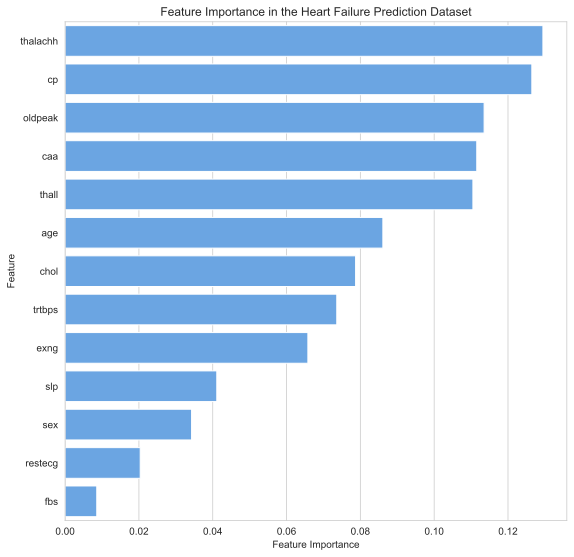

In [30]:
# Plot the feature importances
importance = clf.feature_importances_

# Create a Series with the feature importances
importance = pd.Series(importance, index=X.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(9, 9))
sns.barplot(x=importance, y=importance.index)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Feature Importance in the Heart Failure Prediction Dataset")
plt.show()

Wir haben nun unsere wichtigsten Features mit diesen werden wir nun das Modell trainieren und validieren. 

In [31]:
# New DataFrame with selected features
X= X[selected_features]
X.head()

,age,trtbps,chol,thalachh,oldpeak,caa,cp,thall
0,0.952197,0.763956,-0.256334,0.015443,1.087338,0,3,1
1,-1.915313,-0.092738,0.072199,1.633471,2.122573,0,2,2
2,-1.474158,-0.092738,-0.816773,0.977514,0.310912,0,1,2
3,0.180175,-0.663867,-0.198357,1.239897,-0.206705,0,1,2
4,0.290464,-0.663867,2.082050,0.583939,-0.379244,0,0,2


---

## **6. Modellieren, Trainieren und Validieren**


### 6. 1 Modellieren und Trainieren

Es wurde sich für die **Logistische Regression** und den **Random Forest** entschieden. 

In [32]:
# Splitting the data (80% training 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


**Logistische Regression**

In [33]:
# pipeline 
pipeline_lr = Pipeline([
    ('lr_classifier', LogisticRegression(max_iter=1000, random_state=42) ) 
])

# hyperparameter 
param_grid_lr = {
    'lr_classifier__C': [0.01, 0.1, 1, 10, 100],
    'lr_classifier__solver': ['lbfgs', 'liblinear'],
#    'lr_classifier__penalty': ['l2', 'l1', 'elasticnet'],
#    'lr_classifier__max_iter': [1000, 5000, 10000],
#    'lr_classifier__tol': [1e-4, 1e-3, 1e-5],
#    'lr_classifier__class_weight': [None, 'balanced'],
#    'lr_classifier__fit_intercept': [True, False],
#    'lr_classifier__random_state': [42],
#    'lr_classifier__intercept_scaling': [1, 2, 10],
#    'lr_classifier__warm_start': [True, False]
}

# grid search
grid_search_lr = GridSearchCV(
    pipeline_lr,
    param_grid_lr,
    cv=5,  # cross-validation
    scoring='accuracy',  # metric
    n_jobs=-1  
)

#training
grid_search_lr.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'lr_classifier__C': [0.01, 0.1, ...], 'lr_classifier__solver': ['lbfgs', 'liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 :

**Random Forest**

In [34]:
# pipeline 
pipeline_rf = Pipeline([
    ('rf_classifier', RandomForestClassifier(random_state=42))  
])
# hyperparameter
#eventuell noch mehr hyperparameter hinzufügen
param_grid_rf = {
    'rf_classifier__n_estimators': [50, 100, 200, 500],
    'rf_classifier__max_depth': [None, 10, 20, 50],
    'rf_classifier__min_samples_split': [2, 5, 10],
#    'rf_classifier__min_samples_leaf': [1, 2, 5],
#    'rf_classifier__max_features': ['sqrt', 'log2', None],
#    'rf_classifier__bootstrap': [True, False],
#    'rf_classifier__criterion': ['gini', 'entropy'],
#    'rf_classifier__class_weight': ['balanced', None],
#    'rf_classifier__oob_score': [True, False],
#    'rf_classifier__warm_start': [True, False],
#    'rf_classifier__max_samples': [None, 0.5, 0.75, 1.0]
}

# grid search
grid_search_rf = GridSearchCV(
    pipeline_rf,
    param_grid_rf,
    cv=5,  
    scoring='accuracy', #
    n_jobs=-1  
)

# training
grid_search_rf.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'rf_classifier__max_depth': [None, 10, ...], 'rf_classifier__min_samples_split': [2, 5, ...], 'rf_classifier__n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for

In [35]:
#Logistic Regression
print("The best parameter for Logistic Regression:")
print(grid_search_lr.best_params_)
print("The best accuracy for cross validation for Logistic Regression:")
print(grid_search_lr.best_score_)

The best parameter for Logistic Regression:
{'lr_classifier__C': 0.1, 'lr_classifier__solver': 'lbfgs'}
The best accuracy for cross validation for Logistic Regression:
0.8018707482993198


In [36]:
# Random forest
print("The best parameter for Random Forest:")
print(grid_search_rf.best_params_)
print("The best accuracy for cross validation for Random Forest:")
print(grid_search_rf.best_score_)

The best parameter for Random Forest:
{'rf_classifier__max_depth': None, 'rf_classifier__min_samples_split': 10, 'rf_classifier__n_estimators': 50}
The best accuracy for cross validation for Random Forest:
0.805952380952381


### 6.2 Modelevaluation

In [37]:
# test accuracy for the best models
best_lr_model = grid_search_lr.best_estimator_
best_rf_model = grid_search_rf.best_estimator_

lr_test_predictions = best_lr_model.predict(X_test)
rf_test_predictions = best_rf_model.predict(X_test)

lr_test_accuracy = accuracy_score(y_test, lr_test_predictions)
rf_test_accuracy = accuracy_score(y_test, rf_test_predictions)

print(f"Test accuracy for Logistic Regression: {lr_test_accuracy:.4f}")
print(f"Test accuracy for Random forest: {rf_test_accuracy:.4f}")

Test accuracy for Logistic Regression: 0.8689
Test accuracy for Random forest: 0.8361


In [38]:
# Cross-Validation with RepeatedStratifiedKFold 
cv_repeated = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

# Cross-Validation-Accuracy calculation
lr_cv_scores = cross_val_score(
    best_lr_model, X, y, cv=cv_repeated, scoring='accuracy', n_jobs=-1
)
rf_cv_scores = cross_val_score(
    best_rf_model, X, y, cv=cv_repeated, scoring='accuracy', n_jobs=-1
)

# Output
print(f"Logistic Regression CV Accuracy: {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}")
print(f"Random Forest CV Accuracy: {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}")

Logistic Regression CV Accuracy: 0.8151 ± 0.0425
Random Forest CV Accuracy: 0.8152 ± 0.0476


Logistic Regression AUC: 0.9041
Random Forest AUC: 0.9343


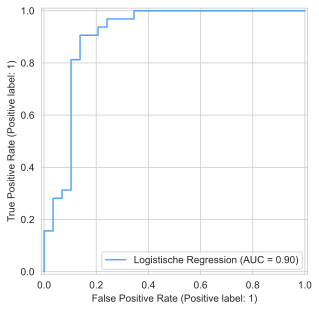

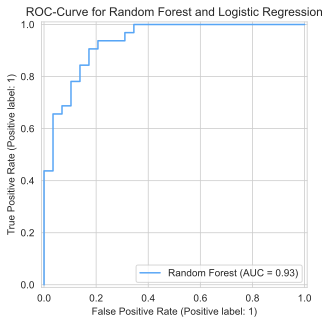

In [39]:
# ROC-Curve and AUC 
#Evaluation metrics
lr_roc_auc = roc_auc_score(y_test, best_lr_model.predict_proba(X_test)[:, 1])
rf_roc_auc = roc_auc_score(y_test, best_rf_model.predict_proba(X_test)[:, 1])

print(f"Logistic Regression AUC: {lr_roc_auc:.4f}")
print(f"Random Forest AUC: {rf_roc_auc:.4f}")

RocCurveDisplay.from_estimator(best_lr_model, X_test, y_test, name="Logistische Regression")
RocCurveDisplay.from_estimator(best_rf_model, X_test, y_test, name="Random Forest")

plt.title("ROC-Curve for Random Forest and Logistic Regression")
plt.show()

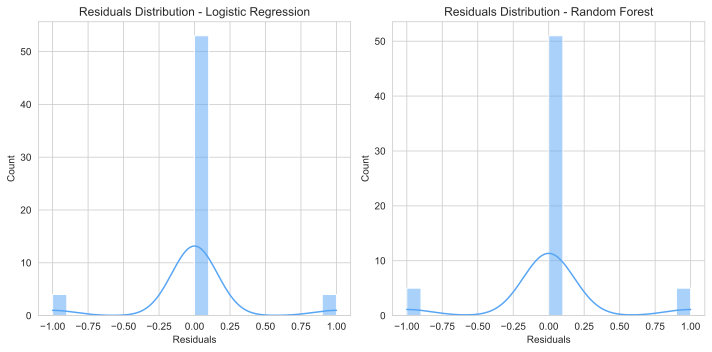

In [40]:
# Residuals distribution
residuals_lr = y_test - lr_test_predictions
residuals_rf = y_test - rf_test_predictions

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.histplot(residuals_lr, kde=True, bins=20)
plt.title("Residuals Distribution - Logistic Regression")
plt.xlabel("Residuals")

plt.subplot(1, 2, 2)
sns.histplot(residuals_rf, kde=True, bins=20)
plt.title("Residuals Distribution - Random Forest")
plt.xlabel("Residuals")

plt.tight_layout()
plt.show()

In [41]:
# Imbalanced classification report 
print("\nLogistic Regression - Classification Report (Imbalanced):")
print(classification_report_imbalanced(y_test, lr_test_predictions))

print("\nRandom Forest - Classification Report (Imbalanced):")
print(classification_report_imbalanced(y_test, rf_test_predictions))


Logistic Regression - Classification Report (Imbalanced):
                   pre       rec       spe        f1       geo       iba       sup

          0       0.86      0.86      0.88      0.86      0.87      0.75        29
          1       0.88      0.88      0.86      0.88      0.87      0.76        32

avg / total       0.87      0.87      0.87      0.87      0.87      0.75        61


Random Forest - Classification Report (Imbalanced):
                   pre       rec       spe        f1       geo       iba       sup

          0       0.83      0.83      0.84      0.83      0.84      0.70        29
          1       0.84      0.84      0.83      0.84      0.84      0.70        32

avg / total       0.84      0.84      0.84      0.84      0.84      0.70        61



In [42]:
# Classification report
print("\nLogistic Regression Classification report:")
print(classification_report(y_test, lr_test_predictions))

print("\nRandom Forest Classification report:")
print(classification_report(y_test, rf_test_predictions))


Logistic Regression Classification report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86        29
           1       0.88      0.88      0.88        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61


Random Forest Classification report:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        29
           1       0.84      0.84      0.84        32

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



### 6.3 Modellvergleich und Interpretation

**Logistische Regression Interpretation:**
- **Gesamtleistung**:
  - Die Logistische Regression erreicht eine Gesamtgenauigkeit von 87%, was auf eine gute Modellleistung hinweist.
- **Klasse 0 (negative Fälle)**:
  - Precision: 86% der vorhergesagten negativen Fälle waren korrekt.
  - Recall: 86% der tatsächlichen negativen Fälle wurden korrekt erkannt.
  - F1-Score: 0.86– Ein ausgewogenes Mass für die Leistung bei der Klasse 0.
- **Klasse 1 (positive Fälle)**:
  - Precision: 88% der vorhergesagten positiven Fälle waren korrekt.
  - Recall: 88% der tatsächlichen positiven Fälle wurden korrekt erkannt.
  - F1-Score: 0.88 - Eine hohe Leistung bei der Klasse 1.

Die logistische Regression ist leicht besser bei der Klasse 1, insbesondere in Bezug auf den Recall, was bedeutet, dass sie weniger positive Fälle verpasst.

**Random Forest Interpretation**
- **Gesamtleistung**:
  - Der Random Forest erreicht eine Gesamtgenauigkeit von 83%.
- **Klasse 0 (negative Fälle)**:
  - Precision: 83% der vorhergesagten negativen Fälle waren korrekt.
  - Recall: 83% der tatsächlichen negativen Fälle wurden korrekt erkannt.
  - F1-Score: 0.83 – Die Leistung ist bei Precision und Recall ausgewogen.
- **Klasse 1 (positive Fälle)**:
  - Precision: 84% der vorhergesagten positiven Fälle waren korrekt.
  - Recall: 84% der tatsächlichen positiven Fälle wurden korrekt erkannt.
  - F1-Score: 0.84 – Eine insgesamt gute Leistung.

Der Random Forest zeigt eine sehr ausgewogene Leistung für beide Klassen.

**Vergleich der Modelle**
- **Logistische Regression**:
  - Insgesamt erreicht die logistische Regression eine etwas bessere Genauigkeit (86% vs. 83%) und übertrifft den Random Forest in allen Kennzahlen (Precision, Recall, F1-Score) für die Klasse 1 (positive Fälle).
  - Dies könnte darauf hindeuten, dass die Logistic Regression besonders gut darin ist, die Zielklasse vorherzusagen, wenn die zugrunde liegende Beziehung linear ist.
- **Random Forest**:
  - Der Random Forest zeigt eine ausgewogene Leistung für beide Klassen, ist jedoch in allen Kennzahlen geringfügig schwächer. Es könnte sein, dass das Modell durch begrenzte Daten oder eine nicht optimale Hyperparameterwahl eingeschränkt wurde.

### 6.4 Verbesserungsmöglichkeiten

**Massnahmen, um die Performance des Modells zu verbessern** 

Es wurde versucht, das Modell auf eine möglichst gute Performance zu optimieren. Dabei wurden folgende Massnahmen unternommen:  

- **Mit den erstellten Features gespielt:**  
    - Es wurden möglichst viele Features erstellt, um deren Performance zu testen. Einige davon zeigten gute Ergebnisse, während viele andere keine Verbesserung für das Modell brachten. 
    - Es wurde festgestellt, dass die erstellten Features am besten unter Verwendung des StandardScalers performen.  
    - Die neu erstellten Features wurden teilweise automatisch entfernt, da sie für das Modell als nicht relevant bewertet wurden.  
    - Beim Erstellen der Features wurde die Accuracy des Modells betrachtet, da zu diesem Zeitpunkt noch keine anderen Variablen zur Bewertung zur Verfügung standen. Dabei wurde mit einer festen Anzahl von 10 Features gearbeitet. Im Nachhinein hätte auch eine Prüfung mit 8 Features vorgenommen werden sollen.  
    -  Schlussendlich wurden keine Features ins Modell genommen, weil die Performance ohne neue Features am Ende am besten war.

- **Die Anzahl der Features im Modell erhöht und reduziert:**  
    - Parallel zur Skalierung und zum Feature Engineering wurde die Anzahl der Features variiert. Die besten Ergebnisse wurden mit 12 Features (auch einige erstelle Features darunter) und dem StandardScaler erzielt. Da jedoch die Gefahr von Overfitting bestand, wurden schlussendlich 8 Features verwendet.

- **Mit der Skalierung gespielt:**  
    - Der StandardScaler wurde ausgewählt, da der MinMaxScaler als zu anfällig für Ausreisser beurteilt wurde. Zwischen dem RobustScaler und dem StandardScaler wurde kaum ein Unterschied festgestellt, weshalb die Wahl auf den StandardScaler fiel. Die erstellten Features funktionierten ebenfalls am besten mit dem StandardScaler. Beim MinMaxScaler wurde teilweise eine Verzerrung der Daten festgestellt, die dies erklären könnte. Beim RobustScaler war die Ursache für schlechtere Ergebnisse weniger klar (z. B. funktionierten logarithmisch erstellte Features nicht).  
    - Es wurde zudem beobachtet, dass der RobustScaler vor allem bei der linearen Regression zu besseren Ergebnissen führte, während dies beim Random Forest nicht der Fall war.  

- **OneHotEncoder getestet:**  
    - Der OneHotEncoder wurde ebenfalls ausprobiert, war jedoch für die gegebenen Daten nicht notwendig und verschlechterte die Ergebnisse.  
- **Hyperparameter:**
    - Ebenfalls wurden noch verschiedene Hyperparameter ausprobiert, jedoch wurde zu wenig Wissen aufgebaut, um wirklich gute Hyperparameter zu verwenden.
- **Imbalanced data:**
    - Da die Daten unverteilt sind, wurden auch hier noch Klassifikationsreport mit den imbalanced Data angeschaut.
    - Bei Änderungen (class_weight = 'balanced' und Smote) haben sich die Paramter (geo und iba) nur verschlechter. Weshalb auf die Methoden schlussendlich verzichtet wurden.

---

## **7. Diskussion und Fazit**



Die logistische Regression hat sich als das leistungsstärkere Modell erwiesen, insbesondere bei der Erkennung positiver Fälle (Klasse 1) mit einer höheren Recall-Rate von 88% im Vergleich zu 88% bei Random Forest. Das bedeutet, dass die logistische Regression besser darin ist, die positiven Fälle zu identifizieren. Der Random Forest zeigt jedoch ebenfalls eine solide Leistung und könnte durch die Optimierung von Hyperparametern wie der Anzahl der Bäume oder der Baumtiefe weiter verbessert werden. Ebenfalls ist RandomForest anfälliger auf Overfitting. Ich habe damit gerechnet, dass beide Modelle ungefähr gleich gut sind, was nun auch eingetreten ist.

Obwohl die logistische Regression die besten Ergebnisse erzielt hat, hätte ich mehr Zeit in die Feinabstimmung der Modelle investieren können. Insbesondere die Hyperparameter des Random Forest hätten durch intensivere Recherche besser angepasst werden können. Auch eine detailliertere Feature-Analyse und das Erstellen zusätzlicher (besserer) Features wäre eventuell hilfreich gewesen, um die Modellleistung weiter zu steigern. Jedoch war mir am Schluss wichtiger nicht den Themen wie Bias, Overfitting etc. in die Falle zu laufen.

Durch das Projekt habe ich ein tieferes Verständnis für Maschinelles Lernen und seine praktische Anwendung gewonnen. Besonders interessant war zu sehen, wie wichtig die Hyperparameter-Optimierung und die Fehleranalyse sind. Ich habe viel über den Kreuzvalidierungsprozess und die iterative Verbesserung von Modellen gelernt und festgestellt, wie wertvoll es ist, flexibel auf neue Erkenntnisse zu reagieren. AI und die Notebooks von Kaggl haben mir wirklich einen guten Leitfaden gegeben und ich konnte mir dadurch viel Wissen aneignen.

Zusammenfassend war das Projekt eine wertvolle Erfahrung, die mein Wissen im Bereich des maschinellen Lernens erheblich erweitert hat.

---

## **8. Quellen**

Für diese Arbeit wurde als Unterstützung (Code und Text) ChatGPT (OpenAI) und CoPilot benutzt.

Für den Code wurden folgende Quellen verwendet:

https://www.kaggle.com/code/ohseokkim/heart-disease-could-our-model-save-lives/notebook

https://www.kaggle.com/code/sonawanelalitsunil/heart-attack-prediction-86

https://www.kaggle.com/code/namanmanchanda/heart-attack-eda-prediction-90-accuracy

https://www.kaggle.com/code/durgancegaur/a-guide-to-any-classification-problem/notebook

Für den Text wurde folgenden Quellen verwendet:

https://www.usz.ch/krankheit/herzinfarkt/